In [1]:
import glob
import ast
import time
import numpy as np
import pandas as pd
from tqdm import tqdm 
import cv2
import json
import collections
from PIL import Image
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import zipfile

from tqdm import tqdm
import shutil

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Loading package

In [3]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [4]:
from py.utils import verifyDir,verifyFile, verifyDataFrame

In [5]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA19/datasets/', '/media/felipe/DATA19/models/')

In [6]:
QSCORE_PATH=f"{cfg.DATA_PATH}pp2/Qscores/"
IMAGES_PATH = f"{cfg.DATA_PATH}pp2/images/"

In [7]:
MODEL_DIR = f"{cfg.MODEL_PATH}"
MODEL_DIR += f"{cfg.SEG_DATASET}_upd4k" if cfg.USE_UPD else f"{cfg.SEG_DATASET}"
MODEL_DIR += "_group/" if cfg.BY_GROUPS else "/"
MODEL_DIR += "" if cfg.USE_UPD else f"{cfg.SEG_MODEL_NAME}/"
MODEL_DIR += f"{cfg.ML_TASK}/"
MODEL_DIR

'/media/felipe/DATA19/models/ade20k_upd4k_group/classifications/'

In [8]:
verifyDir(MODEL_DIR)

### Loading Data and Models

In [9]:
OUT_NAME = f"{cfg.PRECEPTION_METRIC}"
OUT_NAME += "_filter" if cfg.FILTER_FEATURES else ""
OUT_NAME += "_bin" if cfg.BINARIZE_FEATURES else ""
OUT_NAME

'safety'

In [10]:
train_df = pd.read_csv(f"{MODEL_DIR}{OUT_NAME}_data_train.csv", sep=";", low_memory=False)
test_df = pd.read_csv(f"{MODEL_DIR}{OUT_NAME}_data_test.csv", sep=";", low_memory=False)

### Loading model

In [11]:
model_grid = joblib.load(f'{MODEL_DIR}{OUT_NAME}_best.pkl')
model_grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__bootstrap': [True], 'classifier__max_depth': [20], 'classifier__max_features': [None], 'classifier__min_samples_leaf': [3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more me

### Training

In [12]:
feature_names = train_df.iloc[:, 17:-2].columns.tolist()
X_train = train_df.iloc[:, 17:-2].values
y_train = train_df["target"].tolist()

X_test = test_df.iloc[:, 17:-2].values
y_test = test_df["target"].tolist()

In [13]:
len(feature_names), X_train.shape, X_test.shape

(20, (1079, 20), (360, 20))

In [14]:
label_map = dict( zip( train_df['target'], train_df['label'] ) )
label_map

{1: 'safety', 0: 'not safety'}

In [15]:
class_map = dict( zip( train_df['label'], train_df['target'] ) )
class_map

{'safety': 1, 'not safety': 0}

# SHAP(SHapley Additive exPlanations) Explanations

The SHAP value for feature \( i \) is defined as:

$
\phi_i(f, x) =
\sum_{S \subseteq F \setminus \{i\}}
\frac{|S|! (|F| - |S| - 1)!}{|F|!}
\left[
f_{S \cup \{i\}}(x_{S \cup \{i\}})
-
f_S(x_S)
\right]
$

- $F$ = set of all features  
- $S \subseteq F \setminus \{i\}$ = subset of features excluding feature $i$  
- $|S|$ = size of subset $S$  
- $|F|$ = total number of features  
- $f_S(x_S)$ = model trained or evaluated using only features in subset $S$  
- $\phi_i$ = contribution of feature $i$

- **The combinatorial weight**

  $\frac{|S|! (|F| - |S| - 1)!}{|F|!}$

  ensures fair averaging across all possible feature orderings.

- **Additive Explanation Model**
  SHAP explanations follow an additive form:
  
  $g(z') = \phi_0 + \sum_{i=1}^{M} \phi_i z'_i$ $\text{ and }$ $\sum_{i=1}^{M} \phi_i = f(x) - \mathbb{E}[f(x)]$
  
  Where:
    
    - $\phi_0 = \mathbb{E}[f(x)]$ (expected model output / baseline)
    - $\phi_i$ = SHAP value of feature $i$  
    - $z'_i \in \{0,1\}$ indicates presence of feature $i$  
    - $M$ = total number of features

- **Interpretation**
  SHAP computes the average marginal contribution of a feature across all possible subsets of features:

    $\phi_i = \mathbb{E}_S \left[ f_{S \cup \{i\}}(x_{S \cup \{i\}}) - f_S(x_S) \right]$

    This ensures:
    
    - Fair attribution
    - Consistency
    - Additivity
    - Local accuracy

In [16]:
import shap
shap.initjs()

In [17]:
#LinearExplainer
shap_explainer = shap.Explainer(model_grid.best_estimator_[1], X_train)

In [18]:
instance = X_test[0].reshape(1, -1)
contributions = shap_explainer(instance)#, check_additivity=False)
shap_values_dict = dict(zip(feature_names, contributions[0].values))

In [19]:
shap_values_instance = shap_explainer.shap_values(instance)
shap_values_df = pd.DataFrame.from_dict(shap_values_dict, orient='index', columns=list(label_map.values()))

In [20]:
shap_values_df_abs = shap_values_df.abs()
# Or focus on class 1 (e.g., the "positive" class)
shap_class1_df = shap_values_df[['safety']].copy()
shap_class1_df.columns = ['value']
shap_class1_df['feature'] = shap_class1_df.index
top_features = shap_class1_df.reindex(shap_class1_df['value'].abs().sort_values(ascending=False).index[:cfg.TOP_K_FEATURES])

In [21]:
# top_features.loc[(top_features.index=="graffiti"), "value"]*=-1
# top_features.loc[(top_features.index=="broken_damaged_bricks_wall"), "value"]*=-1
# top_features.loc[(top_features.index=="plant"), "value"]*=-1
# top_features.loc[(top_features.index=="streetlight"), "value"]*=-1
# top_features.loc[(top_features.index=="construction"), "value"]*=-1
# top_features.loc[(top_features.index=="sky"), "value"]*=-1
# top_features.loc[(top_features.index=="city_elements"), "value"]*=-1
# top_features.loc[(top_features.index=="person"), "value"]*=-1
# # top_features.loc[(top_features.index=="vegetation"), "value"]*=-1
# top_features.loc[(top_features.index=="terrain_vehicle"), "value"]*=-1
# top_features.loc[(top_features.index=="garbage_bag"), "value"]*=-1
# top_features.loc[(top_features.index=="ground"), "value"]*=-1
# top_features.loc[(top_features.index=="car"), "value"]*=-1

In [22]:
top_features['sign'] = np.sign(top_features['value'])
top_features["color"] = top_features['sign'].map({-1.0: 'red', 1.0: 'blue', 0.0: 'gray'})
top_features

,value,feature,sign,color
city_elements,0.021414,city_elements,1.0,blue
broken_damaged_pavement_road,-0.015570,broken_damaged_pavement_road,-1.0,red
overhead_cable,0.011624,overhead_cable,1.0,blue
broken_damaged_bricks_wall,-0.003208,broken_damaged_bricks_wall,-1.0,red
graffiti,-0.003073,graffiti,-1.0,red
human,0.002519,human,1.0,blue
floor,-0.001356,floor,-1.0,red
garbage_bag,-0.001245,garbage_bag,-1.0,red
sky,-0.000670,sky,-1.0,red
vegetation,-0.000608,vegetation,-1.0,red


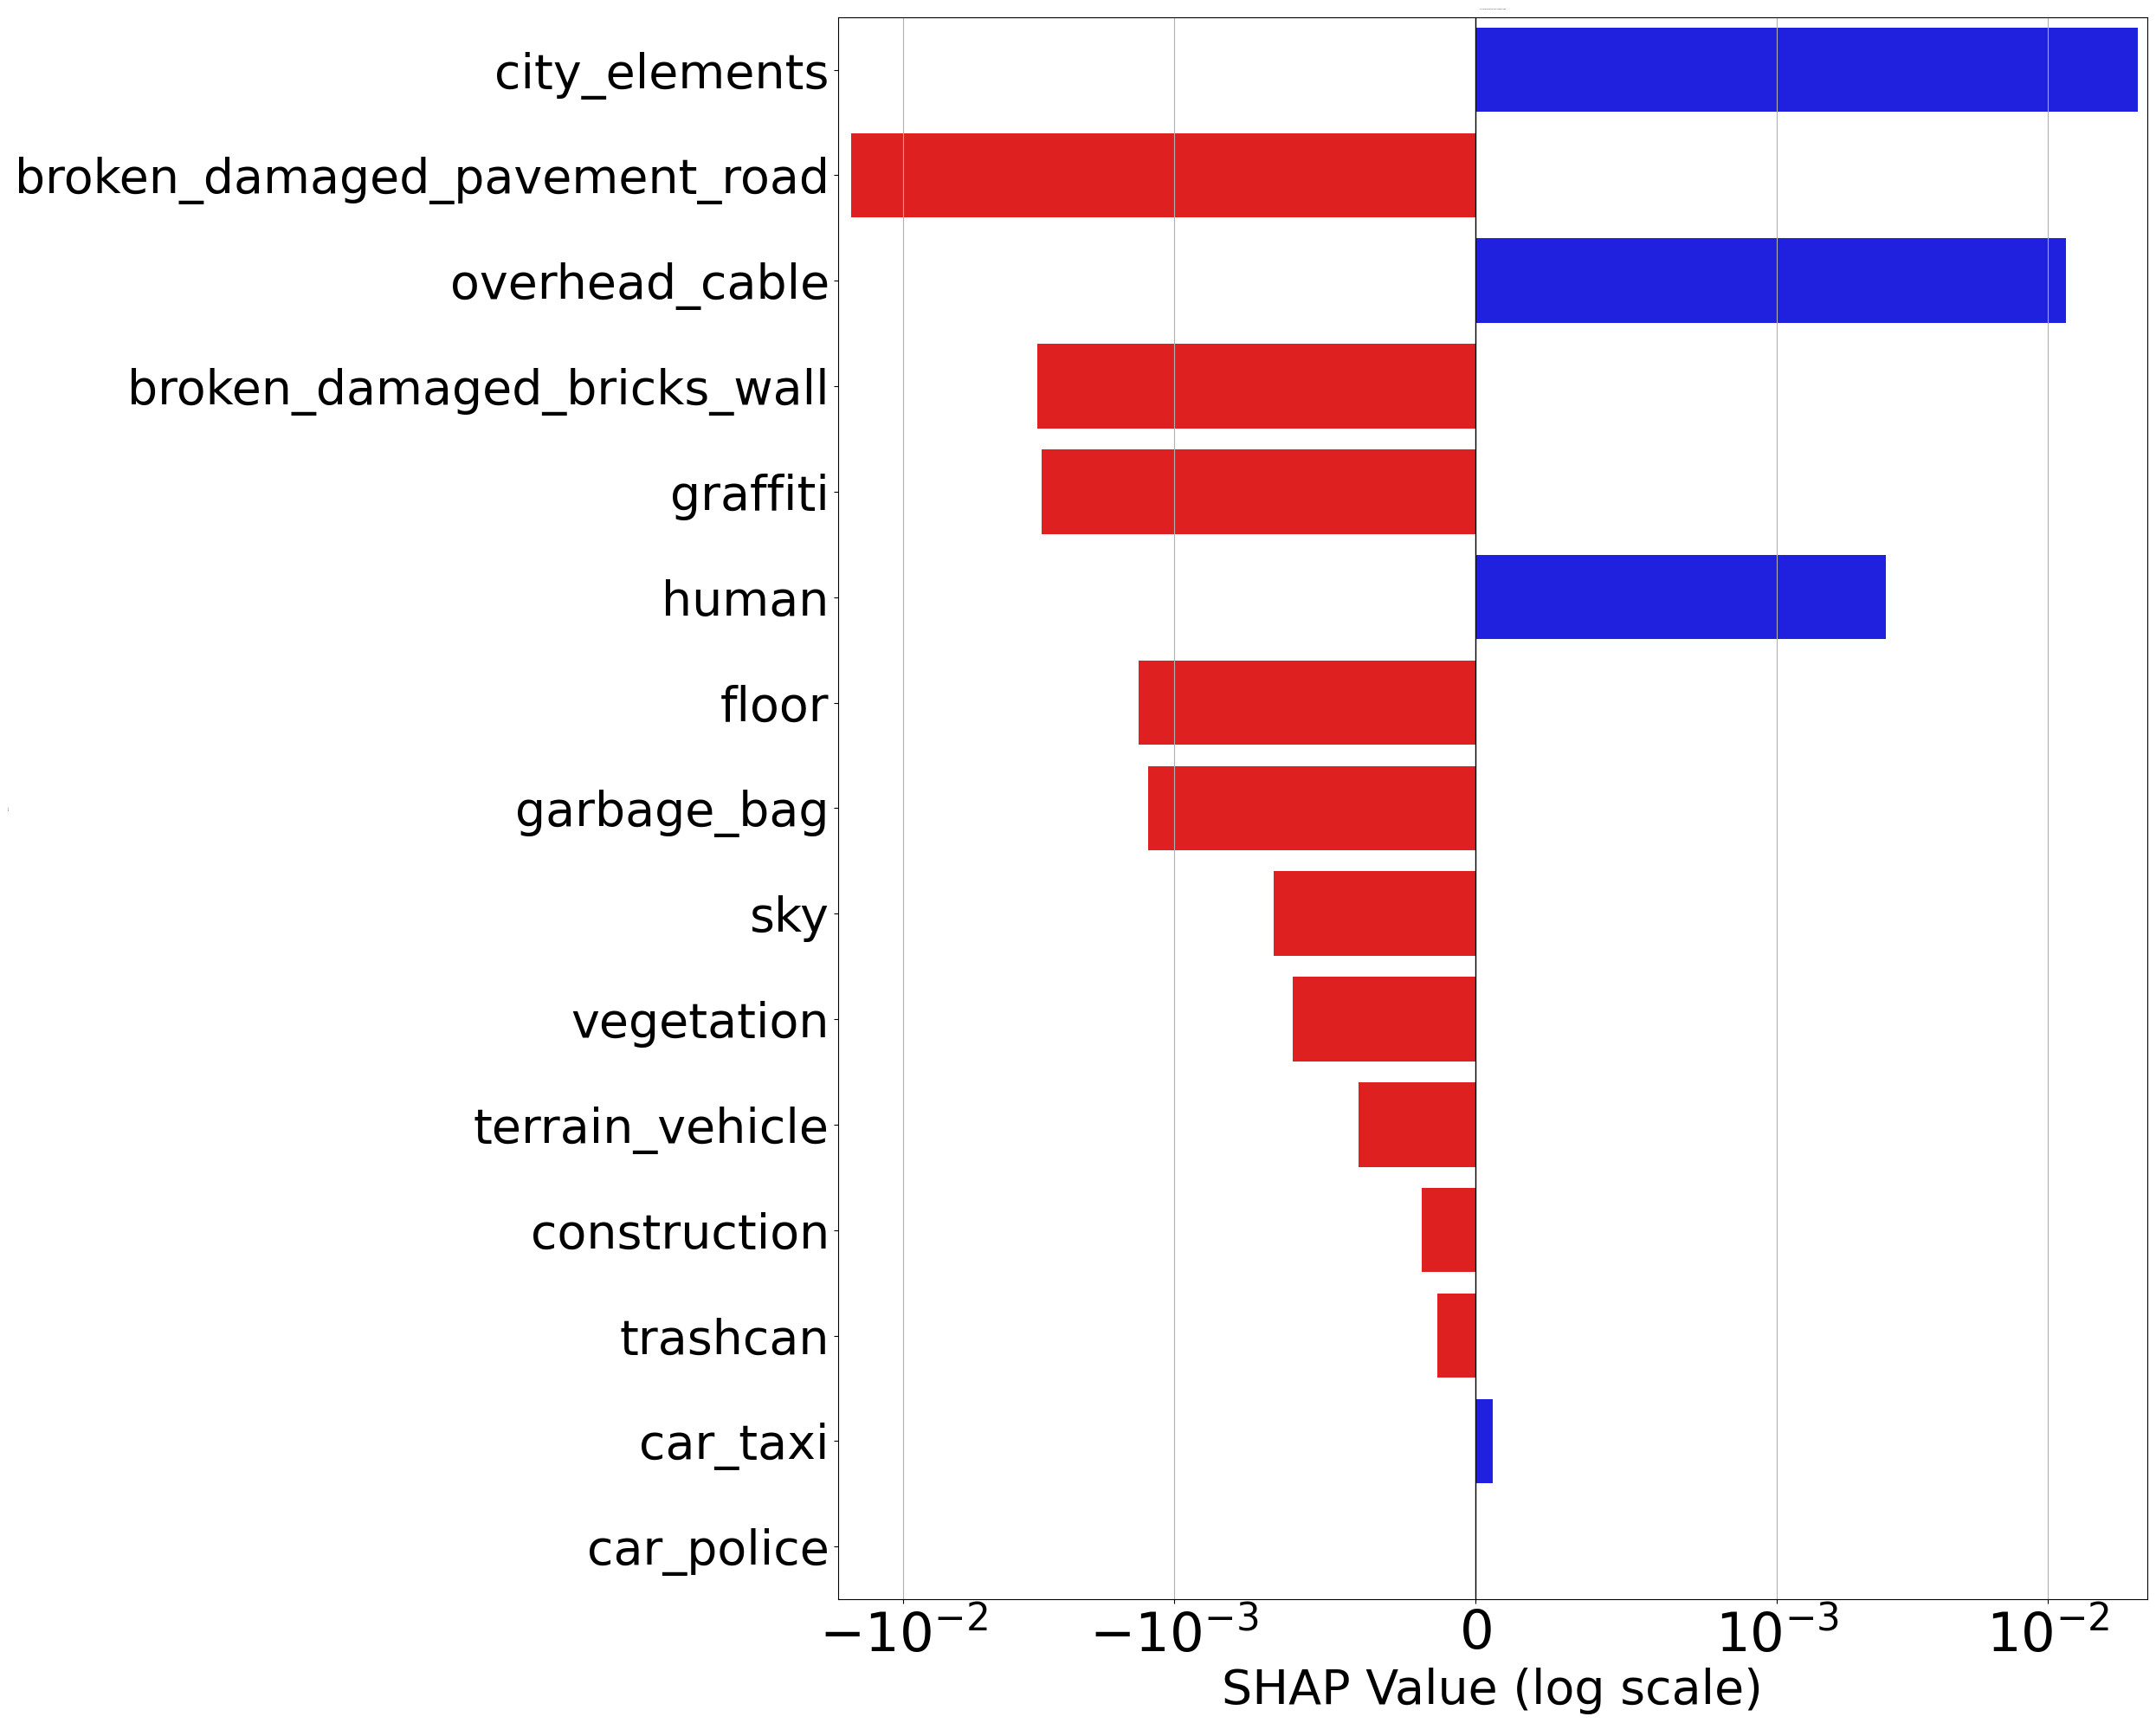

In [23]:
plt.figure(figsize=(25, 20))
sns.barplot(data=top_features, 
            y='feature', 
            x='value', 
            palette=top_features.set_index('feature')['color'].to_dict(),
           )

plt.xscale('symlog', linthresh=0.001)  # handles both positive and negative small values
plt.xlabel('SHAP Value (log scale)', fontsize=40)
plt.ylabel('Feature', fontsize=0)
plt.title('Top 15 SHAP Feature Contributions to safe', fontsize=0)
plt.xticks(fontsize=45)
plt.yticks(fontsize=40)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, axis='x', which='both')
plt.tight_layout()
plt.show()

### Both categories

In [24]:
shap_values_melt_df = shap_values_df_abs.reset_index().melt(id_vars='index', var_name='label', value_name='value')
shap_values_melt_df.rename(columns={'index': 'feature'}, inplace=True)

# Optionally map class labels
# shap_values_melt_df["label"] = shap_values_melt_df["label"].apply(lambda x: class_map[x] if 'label_map' in globals() else x)

# Compute mean impacts
mean_shap_values_df = shap_values_df_abs.sum(axis=1).sort_values(ascending=False).reset_index()
top_k_features_names = mean_shap_values_df["index"][:15].values.tolist()

# Filter and sort
sort_df = shap_values_melt_df[shap_values_melt_df["feature"].isin(top_k_features_names)]
sort_df['feature'] = pd.Categorical(sort_df['feature'], categories=top_k_features_names, ordered=True)
sort_df.sort_values(by=['feature', 'label'], inplace=True)

# Pivot and plot
pivot_df = sort_df.pivot_table(index='feature', columns='label', values='value', aggfunc='sum', fill_value=0)

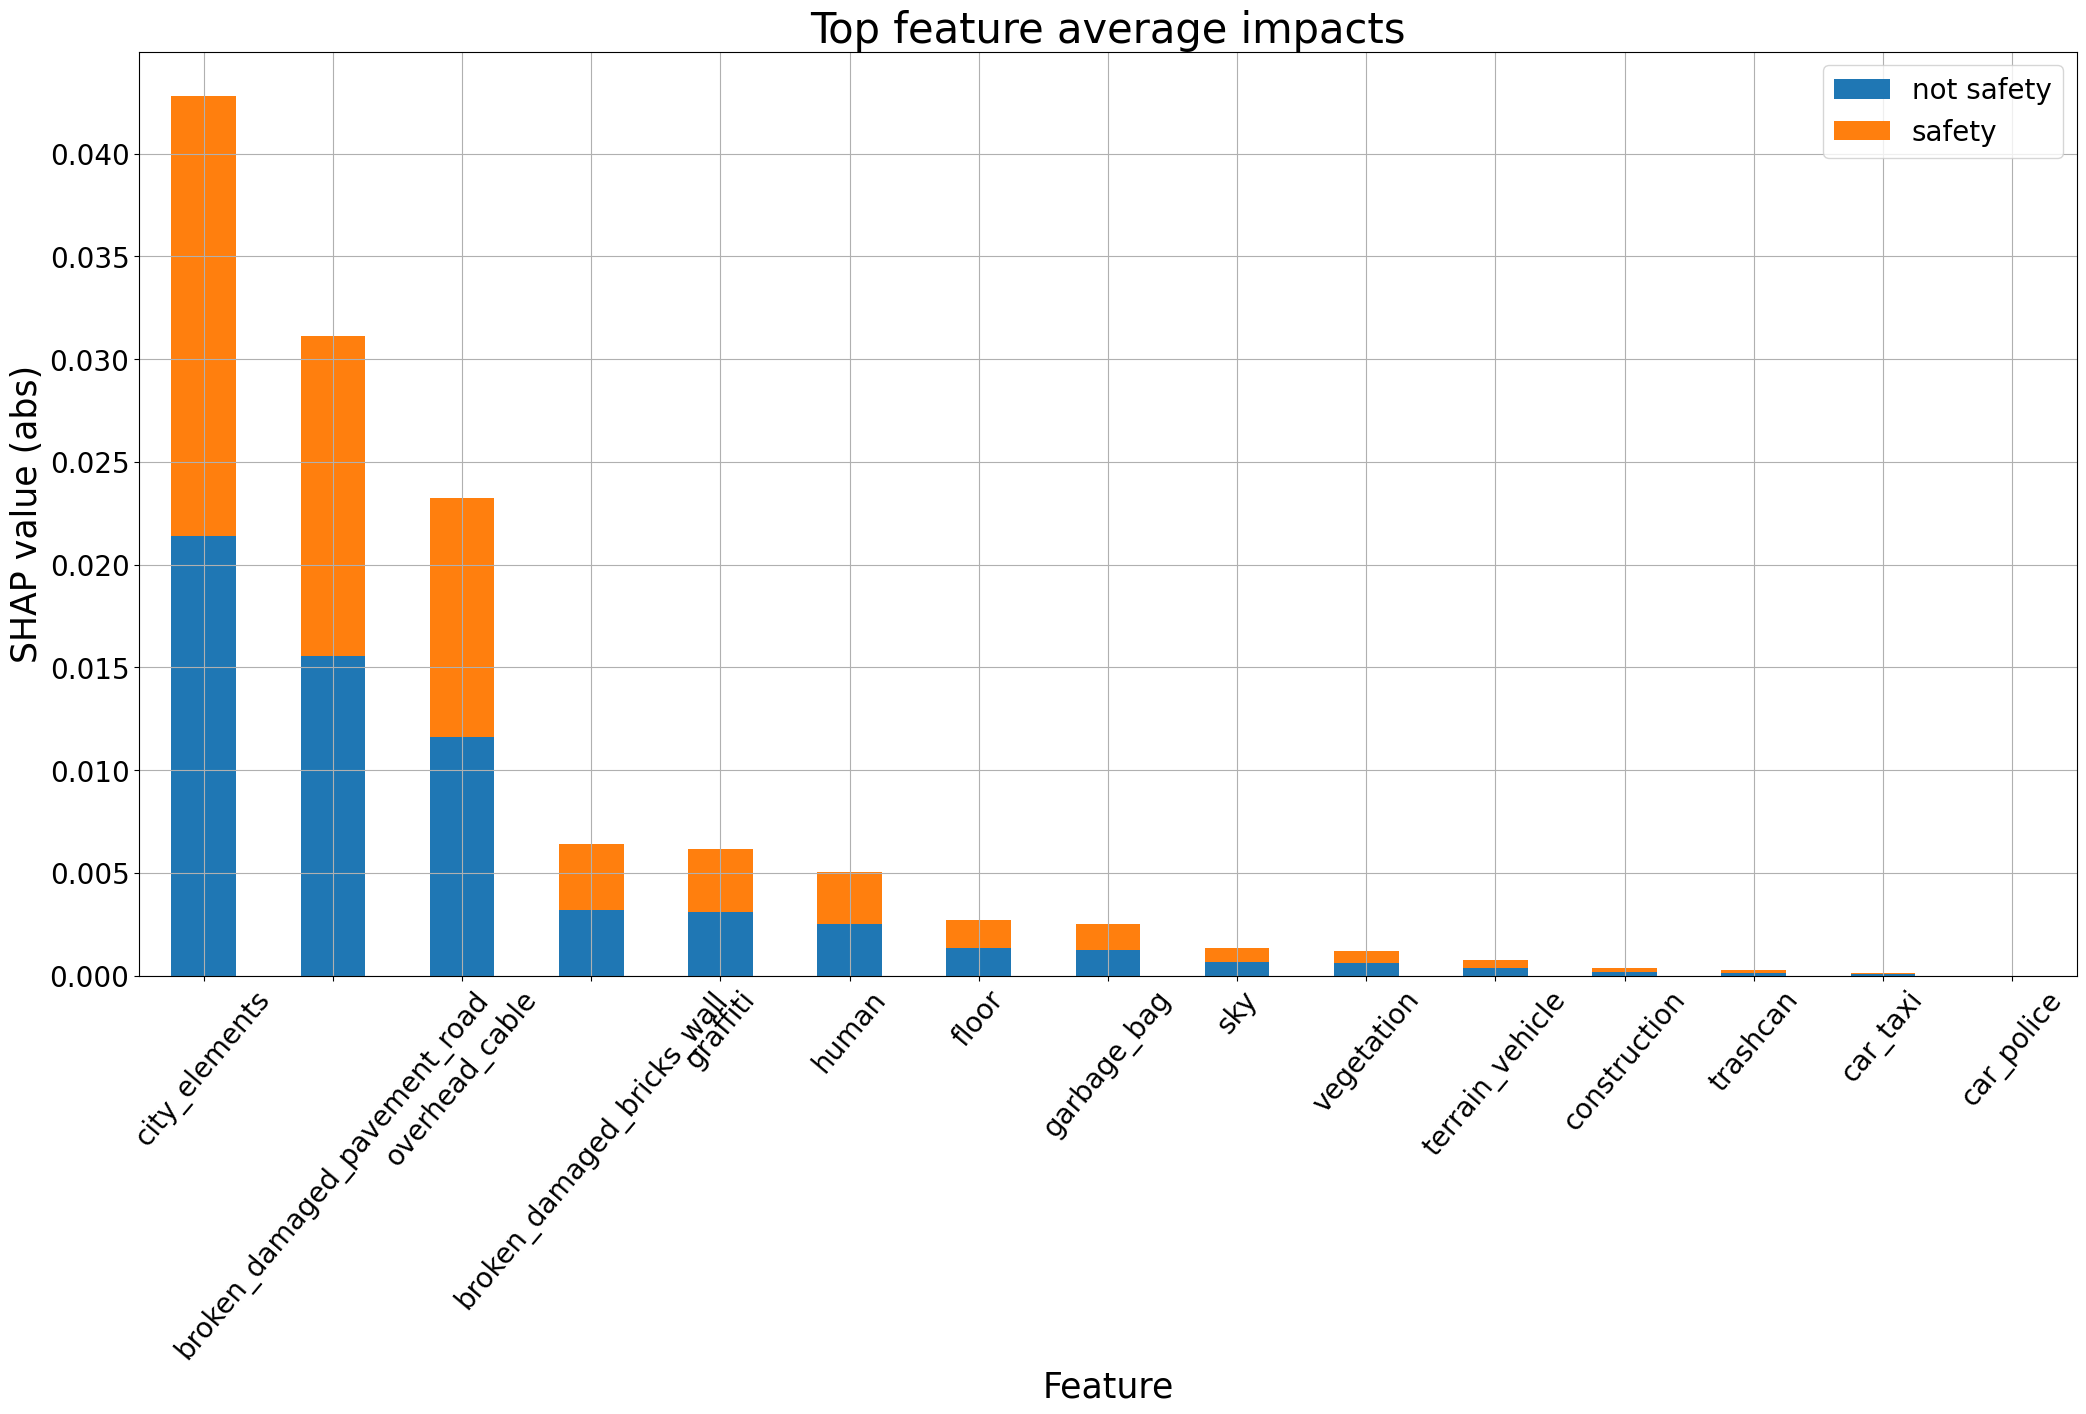

In [25]:
_, ax = plt.subplots(figsize=(25, 12))
pivot_df.plot(kind='bar', stacked=True, ax=ax)

ax.set_title("Top feature average impacts", fontsize=30)
ax.set_xlabel('Feature', fontsize=25)
ax.set_ylabel('SHAP value (abs)', fontsize=25)

ax.tick_params(axis='x', rotation=50, labelsize=20)
ax.tick_params(axis='y', labelsize=20)

ax.legend(fontsize=20)
ax.grid(True)